In [ ]:
from matplotlib import pyplot as plt
%matplotlib inline

In [ ]:
import json
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from google.colab import drive

drive.mount('/content/drive')
root_dir = '/content/drive/MyDrive/'
base_dir = root_dir+"scores/"
# base_dir = '/scratch/ps5688/budgetfusion'
base_dir_data = base_dir + "final/"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Variable Defination

In [ ]:
Dataset_name = "Diff_DB" # Diff_DB and COCO
model_list = ['Turbo', 'DeepCache', 'DDIM', 'Lighting', 'Infinity', 'SDXL'] # the model pool
target_scores = ['clip', 'snr', 'aes', 'imr'] # clip, snr, imr, is/ depending what score you used
need_merge = True # if different steps for one model is in one single file
baseline_tflop = {'SDXL100': 1197, 'SDXL50': 598.5, 'Turbo': 1.54, 'DeepCache': 210, "DDIM": 598.5, "Lighting": 23.92, 'Infinity': 1.5, "FLUX1":59.52, "FLUX15":892.8, "FLUX30": 1785.6}
name_map = {"clip":"CLIPScore", 'snr':"Sharpness", 'aes':"Aesthetic Score", 'imr':"ImageReward"}
t2tflop = {5: 59.85,
  9: 107.73,
  17: 203.49,
  22: 263.34,
  27: 323.19,
  33: 395.01,
  42: 502.74,
  65: 778.05}
  #,
  #100: 1197}

a1, b1 = np.polyfit(list(t2tflop.values()), list(t2tflop.keys()), 1)

a2, b2 = np.polyfit(list(t2tflop.keys()), list(t2tflop.values()), 1)
tflop2t = lambda x: a1*x+b1
t2tflop = lambda x: a2*x+b2
baseline_marker = {
    'Turbo':      'o',   # circle
    'DeepCache':  's',   # square
    'DDIM':       'D',   # diamond
    'Lighting':   '^',   # triangle up
    'Infinity':   'v',    # triangle down
    'FLUX15': '>',        # triangle right
    'FLUX1': '>',
    'FLUX30': '>'
}

baseline_color = {
    'Turbo':      'blue',
    'DeepCache':  'orange',
    'DDIM':       'purple',
    'Lighting':   'cyan',
    'Infinity':   'magenta',
    'FLUX15': 'red',
    'FLUX1': 'blue',
    'FLUX30': 'green'
}

# COCO data

In [ ]:
import torch
base_dir = root_dir+"scores/"

if Dataset_name == "COCO":

  if need_merge:
    f = open(base_dir+"SNR_caption_dir_18384.json", "r")
    SNR_caption_dir = json.load(f)
    f.close()

    f = open(base_dir+"SNR_sdxl100_dir_18384.json", "r")
    SNR_caption_dir_100 = json.load(f)
    f.close()

  SNR_scores = []
  for model_name in model_list:
    f = open(base_dir+f"SNR_{model_name}_dir_18384.json", "r")
    score_dir = json.load(f)
    f.close()
    print(len(score_dir))
    SNR_scores.append(score_dir)

  if need_merge:
    f = open(base_dir+"clip_text_image_score_dict_18384.json", "r")
    clip_text_image_score_dict = json.load(f)
    f.close()

    f = open(base_dir+"sdxl100_clip_score_dict18384.json", "r")
    clip_text_image_score_dict_100 = json.load(f)
    f.close()

  CLIP_scores = []
  for model_name in model_list:
    f = open(base_dir+f"{model_name}_clip_score_dict18384.json", "r")
    score_dir = json.load(f)
    f.close()
    print(len(score_dir))
    CLIP_scores.append(score_dir)

  f = open(base_dir + "select_pairs.json")
  selected_pairs = json.load(f)
  f.close()

  COCO_test_inds = np.load("test_inds (5).npy")

  embedding_path = root_dir+"distinct_prompts_embeddings.pt"
  COCO_test_prompts_embeddings= torch.load(embedding_path)[COCO_test_inds, :768]

KeyboardInterrupt: 

In [ ]:
# merge SDXL scores from different steps and scores of other models into one
all_scores = {}
for score in target_scores:
  all_scores[score] = []
if Dataset_name == "COCO" and need_merge:
  for pair in selected_pairs:
      caption = pair[0].replace(" ", "_")
      caption = caption.replace("/", "_")

      SNR_score = SNR_caption_dir[caption]
      SNR_score_100 = SNR_caption_dir_100[caption]

      CLIP_score = clip_text_image_score_dict[caption]
      CLIP_score_100 = clip_text_image_score_dict_100[caption]

      SNR_add_scores = []
      for score_model in SNR_scores:
          SNR_add_scores.append(list(score_model[caption].values()))

      CLIP_add_scores = []
      for score_model in CLIP_scores:
          CLIP_add_scores.append(list(score_model[caption].values()))

      SNR_add_scores = np.array(SNR_add_scores).T
      CLIP_add_scores = np.squeeze(np.array(CLIP_add_scores)).T

      SNR_temp_scores = []
      CLIP_temp_scores = []
      k=0

      for seed in SNR_score.keys():
          SNR_temp_scores.append([SNR_score_100[seed]]+list(SNR_add_scores[k]))
          CLIP_temp_scores.append(CLIP_score_100[seed]+list(CLIP_add_scores[k]))
          k += 1

      CLIP_temp_scores = np.mean(np.stack(CLIP_temp_scores), axis=0)
      SNR_temp_scores = np.mean(np.stack(SNR_temp_scores), axis=0)

      all_scores["CLIP"].append(CLIP_temp_scores)
      all_scores["SNR"].append(SNR_temp_scores)

  COCO_test_scores = {"CLIP":[], "SNR":[]}
  COCO_test_scores["CLIP"] = np.array([all_scores["CLIP"][i] for i in COCO_test_inds])
  COCO_test_scores["SNR"] = np.exp(-1 * np.array([all_scores["SNR"][i] for i in COCO_test_inds]))
elif Dataset_name == "COCO" and not need_merge:
  for pair in selected_pairs:
    SNR_add_scores = []
    for score_model in SNR_scores:
      SNR_add_scores.append(list(score_model[caption].values()))

    CLIP_add_scores = []
    for score_model in CLIP_scores:
      CLIP_add_scores.append(list(score_model[caption].values()))
    SNR_temp_scores = []
    CLIP_temp_scores = []
    k=0

    for seed in SNR_score.keys():
        SNR_temp_scores.append([SNR_score_100[seed]]+list(SNR_add_scores[k]))
        CLIP_temp_scores.append(CLIP_score_100[seed]+list(CLIP_add_scores[k]))
        k += 1

    CLIP_temp_scores = np.mean(np.stack(CLIP_temp_scores), axis=0)
    SNR_temp_scores = np.mean(np.stack(SNR_temp_scores), axis=0)
    all_scores["CLIP"].append(CLIP_temp_scores)
    all_scores["SNR"].append(SNR_temp_scores)
  COCO_test_scores = {"CLIP":[], "SNR":[]}
  COCO_test_scores["CLIP"] = np.array([all_scores["CLIP"][i] for i in COCO_test_inds])
  COCO_test_scores["SNR"] = np.exp(-1 * np.array([all_scores["SNR"][i] for i in COCO_test_inds]))

In [ ]:
if Dataset_name == "COCO":
  model_names_map = {model_name:i for i, model_name in enumerate(model_names)}

NameError: name 'model_names' is not defined

# Diff_DB data

In [ ]:
if Dataset_name == "Diff_DB":
  f = open(base_dir + "diff_db_select_pairs.json")
  selected_pairs = json.load(f)
  f.close()
  # diffdb_full_prompt_list_97841
  with open(os.path.join(base_dir_data, 'diff_db_select_pairs.json')) as f:
    loaded_json = json.load(f)

  test_inds = np.load(os.path.join(base_dir,'final', 'test_inds_diffdb97k.npy'))

  n_total = len(loaded_json)
  train_inds = list(set(range(n_total))- set(test_inds))

  #further split train into validation and train
  train_inds, val_inds = train_test_split(train_inds, test_size=0.1, random_state=42)
  prompts = [loaded_json[j] for j in range(len(loaded_json))]
  #test_inds = [i for i in test_inds if 'photo' in prompts[i] or 'painting' in prompts[i]]
  #train_inds = [i for i in train_inds if 'photo' in prompts[i] or 'painting' in prompts[i]]
  prompts_te = [loaded_json[test_inds[j]] for j in range(len(test_inds))]
  prompts_tr = [loaded_json[train_inds[j]] for j in range(len(train_inds))]
  prompts_val = [loaded_json[val_inds[j]] for j in range(len(val_inds))]
  with open("diffdb_full_prompt_list_97841.json") as f:
    all_prompts = json.load(f)

  all_prompts = np.array(all_prompts)
  test_prompts = all_prompts[test_inds]
  print(len(test_prompts))

In [ ]:
def load_gt_score(folder, split=None, score_name=None):
    with open(folder,'r') as f:
      data = json.load(f)
    all_score = []
    if not split:
      prompt_list = prompts
    elif split=='train':
      prompt_list = prompts_tr
    elif split=='test':
      prompt_list = prompts_te
    for prompt in prompt_list:
      prompt_clean = prompt[:100].replace(' ','_').replace('/','_')
      score_list = []
      for k,v in data[prompt_clean].items():
        score_list.append(v)
      score_list = np.array(score_list).mean(axis=0)
      all_score.append(score_list)

    all_score = np.array(all_score)
    if score_name:
        if score_name == 'snr':
            all_score = np.exp(-all_score)

    return all_score


In [ ]:
import numpy as np
from collections import defaultdict

if Dataset_name == "Diff_DB":



  #load all score
  scores = defaultdict(dict)

  # scores["hpsv2"]["SDXL"] = load_gt_score(os.path.join(base_dir_data,f'diffdb_hpsv2_score_dict9785.json'), split="test", score_name="hpsv2")
  # for label in extra_labels:
  #     scores["hpsv2"][label] = load_gt_score(os.path.join(base_dir_data,f'{label.lower()}_hpsv2_score_dict9785.json'), split="test", score_name="hpsv2")
  # extra_labels = ["Turbo", "Lighting", "DeepCache", "DDIM", "Infinity", "FLUX1", "FLUX15", "FLUX30"]
  # extra_labels = ["Turbo", "Lighting", "DeepCache", "DDIM", "Infinity", "FLUX30"]

  if need_merge:
    extra_labels = ['Turbo', 'DeepCache', 'DDIM', 'Lighting', 'Infinity']
    extra_timestep = []
    for label in extra_labels:
      extra_timestep.append(tflop2t(baseline_tflop[label]))
      print(f"{label}: {extra_timestep[-1]}")
    for score in target_scores:
        scores[score]["SDXL"] = load_gt_score(os.path.join(base_dir_data,f'diffdb_{score}_score_dict97841.json'), score_name=score)
        for label in extra_labels:
            scores[score][label] = load_gt_score(os.path.join(base_dir_data,f'{label.lower()}_{score}_score_dict97841.json'), score_name=score)
  else:
    for score in target_scores:
      for model in model_list:
        scores[score][model] = load_gt_score(os.path.join(base_dir_data,f'{model.lower()}_{score}_score_dict97841.json'), score_name=score)


NameError: name 'Dataset_name' is not defined

In [ ]:
import torch
if Dataset_name == "Diff_DB":
  embeddings = torch.load(base_dir_data + 'diffdb_prompts_97841_embeddings_mean_part1.pt', map_location=torch.device('cpu'))
  embeddings = np.array(embeddings)
  final_embeddings = embeddings[:,-1,:]
  print(embeddings.shape, final_embeddings.shape)
  X = final_embeddings#torch.from_numpy(embeddings).float()

  # Split into train/test
  X_train = X[train_inds]
  X_val = X[val_inds]
  X_test = X[test_inds]
  # X_test = COCO_test_prompts_embeddings.numpy()



# deferral curve

In [ ]:
def area_under_deferral_curve(costs, rewards, normalize=True):

  costs = np.array(costs)
  rewards = np.array(rewards)
  inds = np.argsort(costs)
  costs = costs[inds]
  rewards = rewards[inds]

  cost_sweep = np.linspace(np.min(costs), np.max(costs), 1000)
  interp_rewards = np.interp(cost_sweep, costs, rewards)

  area = np.trapz(interp_rewards, cost_sweep)
  if normalize:
    return area / (np.max(costs) - np.min(costs))
  else:
    return area


In [ ]:
from typing import Tuple
def sweep_tradeoff_curve(gt_scores, route_scores, costs, lambdas, routing_costs=None, individual_score=False) -> Tuple[np.ndarray, np.ndarray]:
  """Sweep quality-cost trade-off curve.

  Args:
    gt_scores: n x M ground-truth quality scores
    route_scores: n x M
    costs: array of size (M,) containing the costs of the M choices.

  Returns:
    (average costs, average qualities)
  """
  if routing_costs is None:
    routing_costs = costs
  assert route_scores.shape[1] == costs.size
  n = route_scores.shape[0]

  list_tuples = []
  for lamb in lambdas:
    route_inds = np.argmax(route_scores - lamb*routing_costs.reshape(1, -1), axis=1)  # (n,)
    avg_cost = np.mean(costs[route_inds])
    perex_qualities = gt_scores[np.arange(n), route_inds]  # (n,)
    avg_quality = np.mean(perex_qualities)
    std = np.std(perex_qualities)
    if not individual_score:
        list_tuples.append((avg_cost, avg_quality, std))
    else:
        list_tuples.append((avg_cost, avg_quality, std, perex_qualities, route_inds))
  list_tuples = sorted(list_tuples,key=lambda x: x[0])
  all_costs = np.array([t[0] for t in list_tuples])
  all_qualities = np.array([t[1] for t in list_tuples])
  all_std = np.array([t[2] for t in list_tuples])
  if not individual_score:
      return all_costs, all_qualities, all_std
  all_perex_score = np.array([t[3] for t in list_tuples])
  all_inds = np.array([t[4] for t in list_tuples])
  return all_costs, all_qualities, all_std, all_perex_score, all_inds

In [ ]:
import seaborn as sns
sns.set_theme(
    context="paper",       # smaller overall for print
    style="whitegrid",
    font_scale=1.5         # 1.0 = default, 1.5 = 50% larger text
)

In [ ]:
import scipy as sp

def sign_test(metrics1, metrics2):
  """Sign test for H0: equal. H1: metric 2 > metric 1."""
  n_trials = len(metrics1)
  binom = sp.stats.binom(n=n_trials, p=0.5)
  n_wins = np.sum(metrics2 > metrics1)
  p_value = binom.sf(n_wins)
  win_rate = n_wins / n_trials
  return p_value, win_rate


SDXL
SDXL
SDXL
SDXL


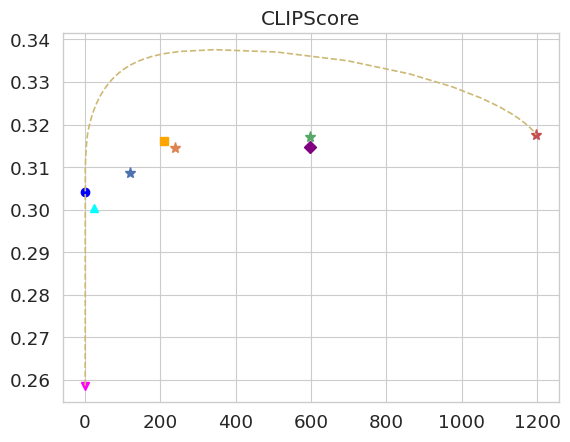

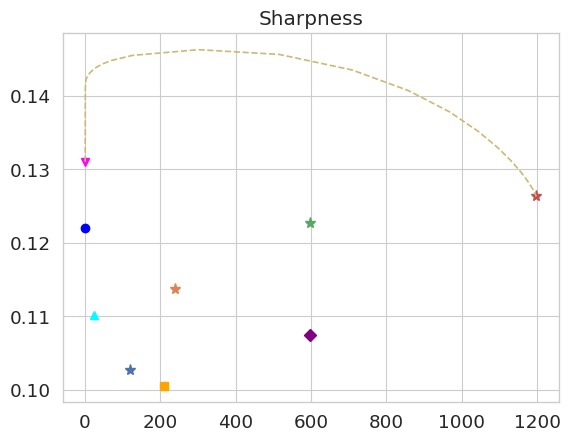

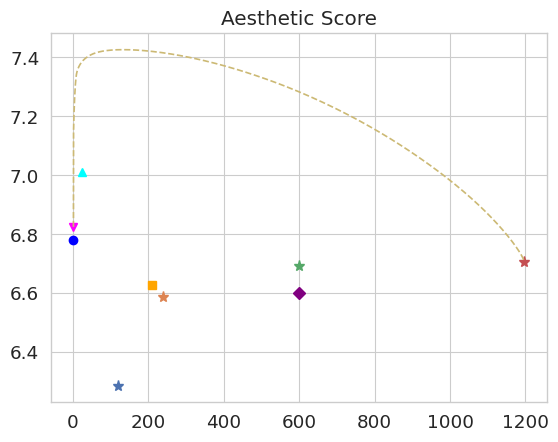

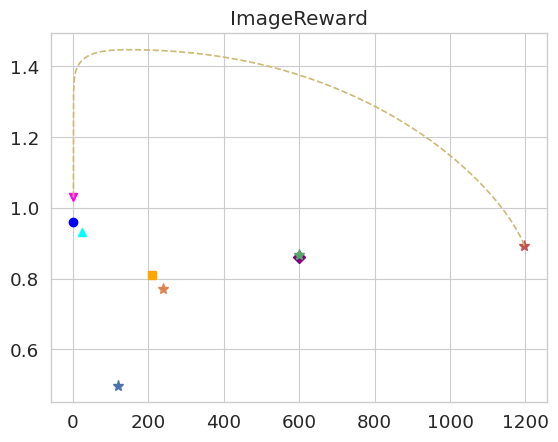

In [ ]:
import sklearn

knn_sweep_all = {}
baseline_score = {}
def force_increase(vector):
  #cur_max = vector[0]
  #for i in range(len(vector)):
  #  cur_max = max(cur_max, vector[i])
  #  vector[i] = cur_max
  return vector
def get_knn_sweep(X_test, X_train, y_test, y_train, costs, n_neighbors=100, lambdas=None, individual_score=False, get_oracal=False):

    if get_oracal:
      return sweep_tradeoff_curve(np.array(y_test), np.array(y_test), costs, lambdas, individual_score=individual_score)
    knn = sklearn.neighbors.NearestNeighbors(n_neighbors=n_neighbors)
    knn.fit(X_train)

    n = X_test.shape[0]
    # radius = 1.1
    kneighbors_te = knn.kneighbors(X_test, return_distance=False)
    # kneighbors_te = knn.radius_neighbors(embeddings_te, radius=radius, return_distance=False)
    knn_scores_te = np.zeros((n, y_test.shape[1]))

    for i in range(n):
      idx = kneighbors_te[i]
      knn_scores_te[i, :] = np.mean(np.array(y_train[idx, :]), axis=0)

    # add noise here

    return sweep_tradeoff_curve(np.array(y_test), knn_scores_te, costs, lambdas, individual_score=individual_score)

lambdas = list(np.linspace(-0.01, 0.07, 10000))
lambdas.extend([0.5, 0.6, 0.7, 0.8, 0.9, 1, 2, 3,4, 5, 1000, 1000000])
lambdas = np.array(lambdas)
model_list = ['Turbo', 'DeepCache', 'DDIM', 'Lighting', 'Infinity', 'SDXL']
model_sort = ["Infinity","Turbo","Lighting", "SDXL10","DeepCache", "SDXL20", "SDXL50",	"DDIM",	"SDXL100"]

# model_list = ['Turbo', 'DeepCache', 'DDIM', 'Lighting', 'Infinity', 'SDXL', "FLUX1", "FLUX15", 'FLUX30']
# model_sort = ["Infinity","Turbo","Lighting", "FLUX1","DeepCache",	"DDIM", "FLUX15",	"SDXL100", 'FLUX30']

# model_list = ['Turbo', 'DeepCache', 'DDIM', 'Lighting', 'Infinity', 'SDXL', 'FLUX15']
# model_sort = ["Infinity","Turbo","Lighting", "DeepCache",	"DDIM", "FLUX15",	"SDXL100"]

# model_list = ['Turbo', 'DeepCache', 'DDIM', "Lighting", 'Infinity', 'SDXL', "FLUX15", 'FLUX30']
# model_sort = ["Infinity","Turbo", "Lighting", "DeepCache",	"DDIM", "FLUX15",	"SDXL100", 'FLUX30']

# model_list = ['Turbo', 'DeepCache', 'DDIM', 'Lighting', 'Infinity', 'SDXL', "FLUX1"]
# model_sort = ["Infinity","Turbo","Lighting", "FLUX1", "DeepCache",	"DDIM",	"SDXL100"]
# model_list = ["FLUX1", "FLUX15", "FLUX30"]
# model_sort = ["FLUX1", "FLUX15", "FLUX30"]

# model_list = ["Turbo", 'DeepCache', 'DDIM', 'Lighting', 'SDXL']
# model_sort = ["Turbo", 'Lighting',"DeepCache",	"DDIM",	"SDXL100"]

# model_list = ['Turbo', 'DeepCache', 'Lighting', 'SDXL', "FLUX"]
# model_sort = ["Turbo","Lighting","DeepCache",	"SDXL50", "FLUX"]

# model_list = ['Turbo', 'DeepCache', 'Lighting', 'SDXL']
# model_sort = ["Turbo","Lighting","DeepCache",	"SDXL50"]

# model_list = ['Turbo', 'DeepCache', 'Lighting', 'SDXL']
# model_sort = ["Turbo","Lighting","DeepCache",	"SDXL100"]

# model_list = ['Turbo', 'DeepCache', 'Lighting']
# model_sort = ["Turbo","Lighting","DeepCache"]

target_scores = ['clip', 'snr', 'aes', 'imr']
# target_scores = ['clip', 'snr']
# target_scores = ['snr', "aes"]

# for score_name, outer_score in scores.items():

all_inds = {}

for score_name in target_scores:
    outer_score = scores[score_name]

    plt.figure()
    model_list = model_list
    current_y_test = []
    #current_y_train = []
    y = []
    all_costs = []
    baseline_score[score_name] = {}
    for model_name in model_list:
        score_data = outer_score[model_name]
        # COCO_score_data = COCO_test_scores[score_name.upper()]
        if model_name == 'SDXL':
            print(model_name)
            timesteps = np.array([5, 10, 15, 20, 50, 100])
            step_to_idx_map = {x: i for i,x in enumerate(timesteps)}
            step_to_include = [ 10, 20, 50, 100]
            # step_to_include = [100]
            step_to_include = sorted(step_to_include)
            baseline_score[score_name][model_name] = []
            for step in step_to_include:
                # print(step)
                #plot base

                score_baseline = np.array(score_data[test_inds,step_to_idx_map[step]])
                # score_baseline = np.array(score_data[train_inds,step_to_idx_map[step]])
                # score_baseline = np.array(scores['hpsv2'][model_name][:,step_to_idx_map[step]])
                # score_baseline = COCO_score_data[:, 0]

                base_qualities = np.mean(score_baseline, axis=0)
                base_std = np.std(score_baseline, axis=0)
                plt.plot(t2tflop(step), base_qualities, marker='*',label=f'SDXL {step}', markersize=8, linestyle='None')

                y.append(score_data[:, step_to_idx_map[step]].reshape((1,-1)))
                current_y_test.append(score_baseline.squeeze())
                all_costs.append(t2tflop(step))

                while type(base_qualities) == list or type(base_qualities) == np.ndarray:
                    base_qualities = base_qualities[0]
                    base_std = base_std[0]
                baseline_score[score_name][model_name].append((base_qualities, base_std))
            #assert 1==2
            #base_qualities = np.mean(np.array(score_data[:,-1]), axis=0)
            #plt.plot(t2tflop(100), base_qualities, 'r*',label='SDXL 100', markersize=8)

        else:
            # print(model_name)
            cost = baseline_tflop[model_name]
            score_baseline = np.array(score_data[test_inds])
            # score_baseline = np.array(score_data[train_inds])
            # score_baseline = np.array(scores['hpsv2'][model_name])
            # score_baseline = COCO_score_data[:, model_names_map[model_name.lower()]+1]

            base_qualities = np.mean(score_baseline, axis=0)
            base_std = np.std(score_baseline, axis=0)
            plt.plot(cost, base_qualities, marker=baseline_marker[model_name], color=baseline_color[model_name],label=model_name, markersize=6, linestyle='None')
            #only consider the last 2 scores
            #for cost in costs:
            #current_y = score_data.reshape(-1,1)

            y.append(score_data.reshape((1,-1)))
            current_y_test.append(score_baseline.squeeze())
            all_costs.append(baseline_tflop[model_name])

            while type(base_qualities) == list or type(base_qualities) == np.ndarray:
                base_qualities = base_qualities[0]
                base_std = base_std[0]
            baseline_score[score_name][model_name] = (base_qualities, base_std)
    all_costs = np.array(all_costs)
    # print(all_costs)
    y = np.array(y)[:,0,:].transpose()
    current_y_test = np.array(current_y_test).T
    # current_y_test = y[test_inds]
    current_y_train = y[train_inds]
    if score_name == 'is':
        lambdas_cur = np.linspace(-0.1, 10, 5000)
    else:
        lambdas_cur = lambdas
    # print(current_y_test.shape)
    knn = get_knn_sweep(X_test, X_train, current_y_test, current_y_train, costs=all_costs, n_neighbors=100, lambdas=lambdas_cur, individual_score=True, get_oracal=True)
    knn_sweep_all[score_name] = (knn[0], force_increase(knn[1]), knn[2], knn[3])
    all_inds[score_name] = knn[4]

    oracle = sweep_tradeoff_curve(np.array(current_y_test), np.array(current_y_test), all_costs, lambdas)

    #plt.plot(oracle[0], force_increase(oracle[1]), 'g--', label='Oracle')
    plt.plot(knn[0], force_increase(knn[1]), 'y--', label=f'Ours')


    #plt.legend()
    plt.title(name_map[score_name])
    #plt.show()
    #if score_name =='clip':
    #    plt.ylim((0,700))
    #assert 1==2
        #break
    plt.savefig(
    f"{score_name}.pdf",        # output filename
    format="pdf",        # PDF format
    bbox_inches="tight", # trim extra whitespace
    pad_inches=0.1,     # small padding
    dpi=600              # resolution for any rasterized elements
)


In [ ]:
all_list = ['Turbo', 'DeepCache', 'DDIM', "Lighting", 'Infinity', 'SDXL10', 'SDXL20', 'SDXL50', 'SDXL100', "FLUX15", "FLUX30"]
['Turbo', 'DeepCache', 'DDIM', "Lighting", 'Infinity', 'SDXL', "FLUX15", 'FLUX30']
len(all_list)

11

In [ ]:
import json

filename = "costs.json"

all_costs = {}
for key, value in knn_sweep_all.items():
  all_costs[key] = value[0].tolist()

with open(filename, 'w') as f:
  json.dump(all_costs, f, indent=1) # indent=4 makes the JSON output human-readable

filename = "scores.json"

all_scores = {}
for key, value in knn_sweep_all.items():
  all_scores[key] = value[1].tolist()

with open(filename, 'w') as f:
  json.dump(all_scores, f, indent=1) # indent=4 makes the JSON output human-readable

filename = "inds.json"

indsss = {}
for key, value in all_inds.items():
  indsss[key] = value.tolist()

with open(filename, 'w') as f:
  json.dump(indsss, f, indent=1) # indent=4 makes the JSON output human-readable

knn_sweep_all["snr"][0]

array([1.5000e+00, 1.5000e+00, 1.5000e+00, ..., 1.7856e+03, 1.7856e+03,
       1.7856e+03])

In [ ]:
import numpy as np

inds = indsss
scores = all_scores
costs = all_costs
keys= ["snr", "aes"]
keys = ["aes"]
indices_dict = {}
for key in keys:
    Indices = np.array(inds[key])
    Score = np.array(scores[key])
    Cost = np.array(costs[key])
    flux_score = Score[-1]
    diff = flux_score - Score
    non_zero_min = np.sort(np.unique(diff[np.nonzero(diff)]))[0]
    # print(np.where(Cost>700)[0][0], Cost)
    # non_zero_min=np.unique(diff[np.nonzero(diff)])[-1]
    # print(key, np.unique(Score[np.nonzero(Score)]))
    cand_indices = np.nonzero(diff==non_zero_min)[0][0]
    cand_indices = np.where(Cost>500)[0][0]
    # cand_indices = 0
    indices_dict[key] = Indices[cand_indices]
    print(key, cand_indices, Indices[cand_indices], np.unique(Indices[cand_indices]), Cost[cand_indices], diff[cand_indices])

aes 8762 [ 3  3 10 ...  3 10 10] [ 0  2  3  4  7  8  9 10] 519.7740950434338 -0.11039078632787458


In [ ]:
all_model_selection = {}
for metric in keys:
  model_selection = []
  for ind in indices_dict[metric]:
    model_selection.append(all_list[ind])
  all_model_selection[metric] = model_selection

In [ ]:
with open("all_model_selection.json", "w") as f:
  json.dump(all_model_selection, f, indent=1)

In [ ]:
Cost[-1]

np.float64(1785.5999999999997)

In [ ]:
from google.colab import files

files.download('costs.json')
files.download('scores.json')
files.download('inds.json')

In [ ]:
def find_score(c, costs, scores, stds):
    st_idx = np.searchsorted(costs, c, side='left')-1
    if st_idx == -1:
        return scores[0], stds[0]
    nx_idx = st_idx + 1

    if nx_idx >= len(scores):
      return scores[st_idx], stds[st_idx]

    # print(max(costs), c)

    v1 = scores[st_idx]
    v2 = scores[nx_idx]

    c1 = costs[st_idx]
    c2 = costs[nx_idx]

    s1 = stds[st_idx]
    s2 = stds[nx_idx]

    t = (c - c1) / (c2 - c1)

    v_interp = v1 + t * (v2 - v1)
    stds_interp = s1 + t*(s2-s1)
    #print(stds_interp)
    return v_interp, stds_interp


def do_sign_test(target_cost, costs, knn_score, score_baseline, stds=None):
    if stds is not None:
        mean_our, std_our = find_score(target_cost, costs, knn_score.mean(axis=1), stds)
        #print(mean_our, std_our)
       # assert 1==2
    else:
        closest_cost = None
        closest_cost_ind = 0
        for i,c in enumerate(costs):
            if c <= target_cost:
              closest_cost = c
              closest_cost_ind = i

        our_score = knn_score[closest_cost_ind]
        mean_our = our_score.mean()
        std_our = our_score.std()
    while len(score_baseline.shape) > 1:
        score_baseline = score_baseline[:,0]
    #print(our_score.shape, score_baseline.shape)
    #return sign_test(score_baseline, our_score)
    return twosample_welch_ttest(score_baseline.mean(), score_baseline.std(), len(score_baseline), mean_our, std_our, len(score_baseline))

import scipy as sp

def twosample_welch_ttest(mean1, std1,  n1, mean2, std2, n2):
  # H0: same mean
  # In the case of one-sided test, H1: mean2 > mean1.
  sbar1 = std1/n1**0.5
  sbar2 = std2/n2**0.5
  tstat = (mean2-mean1) / (sbar1**2 + sbar2**2)**0.5
  v_numer = ((std1**2)/n1 + (std2**2)/n2)**2
  v_denom = (std1**4) / ((n1**2)*(n1-1)) + (std2**4) / ((n2**2)*(n2-1))
  v = v_numer / v_denom
  p = sp.stats.t.sf(tstat, df=v)
  return p


def sign_test(metrics1, metrics2):
  """Sign test for H0: equal. H1: metric 2 > metric 1."""
  n_trials = len(metrics1)
  binom = sp.stats.binom(n=n_trials, p=0.5)
  n_wins = np.sum(metrics2 > metrics1)
  p_value = binom.sf(n_wins)
  win_rate = n_wins / n_trials
  return p_value, win_rate
results = {}

# for score_name, outer_score in scores.items():

for score_name in target_scores:
    outer_score = scores[score_name]
    model_list = sorted(model_list)
    knn_data = knn_sweep_all[score_name]
    knn_score = knn_data[-1]
    costs = knn_data[0]
    print(score_name)
    results[score_name] = {}
    for model_name in model_list:
        score_data = outer_score[model_name]
        # COCO_score_data = COCO_test_scores[score_name.upper()]
        if model_name == 'SDXL':
            timesteps = np.array([5, 10, 15, 20, 50, 100])
            step_to_idx_map = {x: i for i,x in enumerate(timesteps)}
            step_to_include = [10,20,50,100]
            # step_to_include = [5, 10, 15, 20, 50, 100]
            step_to_include = sorted(step_to_include)

            for step in step_to_include:
                target_cost = t2tflop(step)

                score_baseline = np.array(score_data[test_inds,step_to_idx_map[step]])
                # score_baseline = np.array(score_data[train_inds,step_to_idx_map[step]])
                # score_baseline = np.array(scores['hpsv2'][model_name][:, step_to_idx_map[step]])
                # score_baseline = COCO_score_data[:,0]

                p_value = do_sign_test(target_cost, costs, knn_score, score_baseline, stds=knn_data[-2])
                results[score_name][model_name+str(step)] = p_value
                print(step, p_value)


        else:
            target_cost = baseline_tflop[model_name]

            score_baseline = np.array(score_data[test_inds])
            # score_baseline = np.array(score_data[train_inds])
            # score_baseline = np.array(scores['hpsv2'][model_name]).squeeze()
            # score_baseline = COCO_score_data[:, model_names_map[model_name.lower()]+1]

            p_value = do_sign_test(target_cost, costs, knn_score, score_baseline,stds=knn_data[-2])
            results[score_name][model_name] = p_value
            print(model_name, p_value)

    print('\n\n')

clip
DDIM 1.17260531354765e-310
DeepCache 1.021409763743572e-284
Infinity 0.5
Lighting 0.0
10 0.0
20 0.0
50 5.792711240366424e-278
100 0.4999999999999583
Turbo 3.640686374214871e-17



snr
DDIM 0.0
DeepCache 0.0
Infinity 0.5
Lighting 0.0
10 0.0
20 0.0
50 0.0
100 0.4999999999999443
Turbo 0.0



aes
DDIM 0.0
DeepCache 0.0
Infinity 0.5
Lighting 1.212069449033393e-208
10 0.0
20 0.0
50 0.0
100 0.49999999999996897
Turbo 2.59178102935226e-183



imr
DDIM 0.0
DeepCache 0.0
Infinity 0.5
Lighting 0.0
10 0.0
20 0.0
50 0.0
100 0.4999999999999617
Turbo 3.549882434153895e-238





In [ ]:
import pandas as pd
pd.set_option('display.float_format', '{:.2e}'.format)
df = pd.DataFrame(results).transpose()

In [ ]:
def bold_low_p(val):
    return f"\\textbf{{{val:.3e}}}" if val < 0.05 else f"{val:.3e}"

df_latex = df.applymap(bold_low_p)

/tmp/ipython-input-3080801856.py:4: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_latex = df.applymap(bold_low_p)


In [ ]:
print(df_latex.transpose().to_latex(index=True,float_format="{:.2e}".format))

\begin{tabular}{lllll}
\toprule
 & clip & snr & aes & imr \\
\midrule
DDIM & \textbf{1.173e-310} & \textbf{0.000e+00} & \textbf{0.000e+00} & \textbf{0.000e+00} \\
DeepCache & \textbf{1.021e-284} & \textbf{0.000e+00} & \textbf{0.000e+00} & \textbf{0.000e+00} \\
Infinity & 5.000e-01 & 5.000e-01 & 5.000e-01 & 5.000e-01 \\
Lighting & \textbf{0.000e+00} & \textbf{0.000e+00} & \textbf{1.212e-208} & \textbf{0.000e+00} \\
SDXL10 & \textbf{0.000e+00} & \textbf{0.000e+00} & \textbf{0.000e+00} & \textbf{0.000e+00} \\
SDXL20 & \textbf{0.000e+00} & \textbf{0.000e+00} & \textbf{0.000e+00} & \textbf{0.000e+00} \\
SDXL50 & \textbf{5.793e-278} & \textbf{0.000e+00} & \textbf{0.000e+00} & \textbf{0.000e+00} \\
SDXL100 & 5.000e-01 & 5.000e-01 & 5.000e-01 & 5.000e-01 \\
Turbo & \textbf{3.641e-17} & \textbf{0.000e+00} & \textbf{2.592e-183} & \textbf{3.550e-238} \\
\bottomrule
\end{tabular}



In [ ]:
import pandas as pd

pd.DataFrame(results)

,clip,snr,aes,imr
DDIM,1.17e-310,0.00e+00,0.00e+00,0.00e+00
DeepCache,1.02e-284,0.00e+00,0.00e+00,0.00e+00
Infinity,5.00e-01,5.00e-01,5.00e-01,5.00e-01
Lighting,0.00e+00,0.00e+00,1.21e-208,0.00e+00
SDXL10,0.00e+00,0.00e+00,0.00e+00,0.00e+00
SDXL20,0.00e+00,0.00e+00,0.00e+00,0.00e+00
SDXL50,5.79e-278,0.00e+00,0.00e+00,0.00e+00
SDXL100,5.00e-01,5.00e-01,5.00e-01,5.00e-01
Turbo,3.64e-17,0.00e+00,2.59e-183,3.55e-238


In [ ]:
costs = knn_data[0]
closest_cost = None
closest_cost_ind = 0
for i,c in enumerate(costs):
    if c <= target_cost:
      closest_cost = c
      closest_cost_ind = i
our_score = knn_score[closest_cost_ind]

In [ ]:
import pandas as pd
def cost_to_be_neutral(costs, rewards, target_reward: float, epsilon=1e-4):
  costs = np.array(costs)
  rewards = np.array(rewards)
  inds = np.argsort(costs)
  costs = costs[inds]
  rewards = rewards[inds]

  cost_sweep = np.linspace(np.min(costs), np.max(costs), 5000)
  interp_rewards = np.interp(cost_sweep, costs, rewards)
  reach_inds = target_reward - epsilon - interp_rewards <= 0
  where = np.argwhere(reach_inds)
  if  len(where) <= 0:
    # Can't reach the target reward.
    return np.inf
  cost_ind = where[0]
  target_cost = cost_sweep[cost_ind]
  return target_cost[0]


results = {}

# for score_name, outer_score in scores.items():

for score_name in target_scores:
    outer_score = scores[score_name]

    print(score_name)
    model_list = sorted(model_list)
    results[score_name.upper()] = {}
    for model_name in model_list:
        knn = knn_sweep_all[score_name]

        if model_name == 'SDXL':
            timesteps = np.array([5, 10, 15, 20, 50, 100])
            step_to_idx_map = {x: i for i,x in enumerate(timesteps)}
            step_to_include = [10,20,50,100]
            # step_to_include = [5, 10, 15, 20, 50, 100]
            step_to_include = sorted(step_to_include)
            #baseline_score[score_name][model_name] = []
            for i, step in enumerate(step_to_include):
                model_cost = t2tflop(step)
                largest_step_reward, std = baseline_score[score_name][model_name][i]

                qnc = cost_to_be_neutral(knn[0], knn[1], target_reward=largest_step_reward, epsilon=1e-4)
                print(model_name)#, step,model_cost, largest_step_reward)
                print('\t',qnc, qnc/model_cost)
                results[score_name.upper()][model_name+str(step)] = 100*qnc/model_cost
                #assert 1==2
        else:
            model_cost = baseline_tflop[model_name]
            largest_step_reward, std = (baseline_score[score_name][model_name])
            if type(largest_step_reward) != float and type(largest_step_reward) != np.float64:
                largest_step_reward = largest_step_reward[0]
            qnc = cost_to_be_neutral(knn[0], knn[1], target_reward=largest_step_reward, epsilon=1e-4)
            print(model_name)#, model_cost, largest_step_reward)
            print('\t',qnc, qnc/model_cost)
            results[score_name.upper()][model_name] = 100*qnc/model_cost
    print()

clip
DDIM
	 4.369773954790958 0.007301209615356655
DeepCache
	 5.804660932186437 0.027641242534221126
Infinity
	 1.5 1.0
Lighting
	 1.739147829565913 0.0727068490621201
SDXL
	 1.739147829565913 0.014529221633800467
SDXL
	 4.369773954790958 0.018253024038391654
SDXL
	 6.761252250450089 0.011296996241353538
SDXL
	 7.478695739147828 0.0062478661145763
Turbo
	 1.739147829565913 1.129316772445398

snr
DDIM
	 1.5 0.002506265664160401
DeepCache
	 1.5 0.007142857142857143
Infinity
	 1.5 1.0
Lighting
	 1.5 0.06270903010033445
SDXL
	 1.5 0.012531328320802025
SDXL
	 1.5 0.006265664160401008
SDXL
	 1.5 0.0025062656641604026
SDXL
	 1.5 0.001253132832080201
Turbo
	 1.5 0.974025974025974

aes
DDIM
	 1.5 0.002506265664160401
DeepCache
	 1.5 0.007142857142857143
Infinity
	 1.5 1.0
Lighting
	 1.739147829565913 0.0727068490621201
SDXL
	 1.5 0.012531328320802025
SDXL
	 1.5 0.006265664160401008
SDXL
	 1.5 0.0025062656641604026
SDXL
	 1.5 0.001253132832080201
Turbo
	 1.5 0.974025974025974

imr
DDIM
	 1.5 0.

In [ ]:
qnc_df = pd.DataFrame.from_dict(results)
qnc_df = qnc_df.transpose()

qnc_df = qnc_df[model_sort]#.round(2)
qnc_df

,Infinity,Turbo,Lighting,SDXL10,DeepCache,SDXL20,SDXL50,DDIM,SDXL100
CLIP,1.00e+02,1.13e+02,7.27e+00,1.45e+00,2.76e+00,1.83e+00,1.13e+00,7.30e-01,6.25e-01
SNR,1.00e+02,9.74e+01,6.27e+00,1.25e+00,7.14e-01,6.27e-01,2.51e-01,2.51e-01,1.25e-01
AES,1.00e+02,9.74e+01,7.27e+00,1.25e+00,7.14e-01,6.27e-01,2.51e-01,2.51e-01,1.25e-01
IMR,1.00e+02,9.74e+01,6.27e+00,1.25e+00,7.14e-01,6.27e-01,2.51e-01,2.51e-01,1.25e-01


In [ ]:
print((qnc_df.to_latex(index=False)))

\begin{tabular}{rrrrrrrrr}
\toprule
Infinity & Turbo & Lighting & SDXL10 & DeepCache & SDXL20 & SDXL50 & DDIM & SDXL100 \\
\midrule
100.000000 & 112.931677 & 7.270685 & 1.452922 & 2.764124 & 1.825302 & 1.129700 & 0.730121 & 0.624787 \\
100.000000 & 97.402597 & 6.270903 & 1.253133 & 0.714286 & 0.626566 & 0.250627 & 0.250627 & 0.125313 \\
100.000000 & 97.402597 & 7.270685 & 1.253133 & 0.714286 & 0.626566 & 0.250627 & 0.250627 & 0.125313 \\
100.000000 & 97.402597 & 6.270903 & 1.253133 & 0.714286 & 0.626566 & 0.250627 & 0.250627 & 0.125313 \\
\bottomrule
\end{tabular}



In [ ]:
def find_score(c, costs, scores, stds):
    st_idx = np.searchsorted(costs, c, side='left')-1
    if st_idx == -1:
        return scores[0], stds[0]
    nx_idx = st_idx + 1

    if nx_idx >= len(scores):
      return scores[st_idx], stds[st_idx]



    c1 = costs[st_idx]
    c2 = costs[nx_idx]
    print(c, c1, c2)

    v1 = scores[st_idx]
    v2 = scores[nx_idx]

    s1 = stds[st_idx]
    s2 = stds[nx_idx]

    t = (c - c1) / (c2 - c1)

    v_interp = v1 + t * (v2 - v1)
    stds_interp = s1 + t*(s2-s1)
    #print(stds_interp)
    return v_interp, stds_interp


In [ ]:
final_score_list = {}
std_norm = (len(current_y_test)**0.5)
# for score_name in scores.keys():
for score_name in target_scores:
    print('====================')
    print(score_name)
    knn = knn_sweep_all[score_name]
    model_list = sorted(model_list)
    final_score_list[score_name] = []
    for model_name in model_list:
        if model_name == 'SDXL':
            for i, step in enumerate(step_to_include):
                #print(t2tflop(step))
                cost = t2tflop(step)
                v, std = find_score(cost, knn[0], knn[1], knn[2])
                base_score, base_std = baseline_score[score_name][model_name][i]
                final_score_list[score_name].append((model_name+'-'+str(step), cost, v, std/std_norm, base_score, base_std/std_norm))
                # print(v, base_score, f'{model_name}: {step}')
        else:
            cost = baseline_tflop[model_name]
            v, std = find_score(cost, knn[0], knn[1], knn[2])
            base_score, base_std = baseline_score[score_name][model_name]
            while type(base_score) == list or type(base_score) == np.ndarray:
                base_score = base_score[0]
                base_std = base_std[0]
            final_score_list[score_name].append((model_name, cost, v, std/std_norm, base_score, base_std/std_norm))
            #assert 1==2
            # print(v, base_score, f'{model_name}')


clip
598.5 508.6518201328563 696.460098109351
210 207.35294225855898 252.44101788451707
23.92 23.400545733265194 24.612543689320376
119.6999999999998 110.11146244251402 122.48262646908529
239.39999999999978 207.35294225855898 252.44101788451707
598.4999999999997 508.6518201328563 696.460098109351
1196.9999999999995 1196.938834951456 1196.9999999999998
1.54 1.538759325498211 1.5410505876341336
snr
598.5 516.3753888605006 709.5336371997955
210 126.60657741440976 302.056228921819
23.92 18.033120081757787 24.160004087889618
119.6999999999998 69.83539499233518 126.60657741440976
239.39999999999978 126.60657741440976 302.056228921819
598.4999999999997 516.3753888605006 709.5336371997955
1196.9999999999995 1196.938834951456 1196.9999999999998
1.54 1.537034236075626 1.5416085845682164
aes
598.5 596.7966601941746 605.2725682166581
210 206.27964639754725 211.84469289729174
23.92 23.884459887583034 23.92935922330097
119.6999999999998 118.03493510475215 120.377336739908
239.39999999999978 235.5750

In [ ]:
import pandas as pd
df_list = []
# for score_name in scores.keys():
for score_name in target_scores:
    data = {name: [x, y, z, a, b] for name, x, y, z, a, b in final_score_list[score_name]}
    #if score_name == 'snr':
    #    score_name = 'sharp'
    df = pd.DataFrame.from_dict(
        data,
        orient='index',
        columns=['Cost', f'{score_name.upper()} Routing', f'{score_name.upper()} Routing STD', f'{score_name.upper()} Fixed', f'{score_name.upper()} Fixed STD']
    )

    df.index.name = 'Model'
    #df.reset_index(inplace=True)

    df_list.append(df.sort_values('Cost'))



In [ ]:
pd.options.display.float_format = '{:.9f}'.format

In [ ]:
df_result = df_list[0]

for i in range(1,len(df_list)):
    df_result = pd.merge(df_result.reset_index(), df_list[i].reset_index(), on='Model', suffixes=('0', '1'))
    df_result = df_result.drop(columns=['Cost1', 'Cost0'], errors='ignore')#.rename(columns={'Cost0':'TFlops'})
    #df_result.transpose()
df_result = df_result.drop(columns=['level_0','index', 'Cost'], errors='ignore')
df_result.transpose()

,0,1,2,3,4,5,6,7,8
Model,Infinity,Turbo,Lighting,SDXL-10,DeepCache,SDXL-20,SDXL-50,DDIM,SDXL-100
CLIP Routing,0.258633669,0.308994973,0.323263219,0.333883877,0.336642084,0.337013365,0.336066792,0.336066792,0.317570730
CLIP Routing STD,0.000586866,0.000403528,0.000386779,0.000372233,0.000367573,0.000366782,0.000368856,0.000368856,0.000375710
CLIP Fixed,0.258633669,0.304126278,0.300433839,0.308532344,0.316150092,0.314595779,0.317003570,0.314703239,0.317570730
CLIP Fixed STD,0.000586866,0.000420893,0.000442628,0.000384369,0.000421176,0.000375036,0.000376040,0.000417211,0.000375710
SNR Routing,0.131005381,0.140249759,0.143599593,0.145409102,0.145865353,0.145996088,0.144723616,0.144723616,0.126298971
SNR Routing STD,0.000358135,0.000335490,0.000348748,0.000348946,0.000347486,0.000346962,0.000354270,0.000354270,0.000281200
SNR Fixed,0.131005381,0.122064536,0.110193533,0.102675001,0.100549590,0.113761881,0.122686875,0.107401347,0.126298971
SNR Fixed STD,0.000358135,0.000267422,0.000301173,0.000163532,0.000247509,0.000225423,0.000266732,0.000265510,0.000281200
AES Routing,6.824070597,7.131570473,7.385202968,7.426279739,7.420575118,7.415847951,7.283859465,7.283859465,6.706729919


In [ ]:
df = df_result.transpose()

In [ ]:
df

,0,1,2,3,4,5,6,7,8
Model,Infinity,Turbo,Lighting,SDXL-10,DeepCache,SDXL-20,SDXL-50,DDIM,SDXL-100
CLIP Routing,0.258633669,0.308994973,0.323263219,0.333883877,0.336642084,0.337013365,0.336066792,0.336066792,0.317570730
CLIP Routing STD,0.000586866,0.000403528,0.000386779,0.000372233,0.000367573,0.000366782,0.000368856,0.000368856,0.000375710
CLIP Fixed,0.258633669,0.304126278,0.300433839,0.308532344,0.316150092,0.314595779,0.317003570,0.314703239,0.317570730
CLIP Fixed STD,0.000586866,0.000420893,0.000442628,0.000384369,0.000421176,0.000375036,0.000376040,0.000417211,0.000375710
SNR Routing,0.131005381,0.140249759,0.143599593,0.145409102,0.145865353,0.145996088,0.144723616,0.144723616,0.126298971
SNR Routing STD,0.000358135,0.000335490,0.000348748,0.000348946,0.000347486,0.000346962,0.000354270,0.000354270,0.000281200
SNR Fixed,0.131005381,0.122064536,0.110193533,0.102675001,0.100549590,0.113761881,0.122686875,0.107401347,0.126298971
SNR Fixed STD,0.000358135,0.000267422,0.000301173,0.000163532,0.000247509,0.000225423,0.000266732,0.000265510,0.000281200
AES Routing,6.824070597,7.131570473,7.385202968,7.426279739,7.420575118,7.415847951,7.283859465,7.283859465,6.706729919


In [ ]:
df.to_csv('quan_table.csv')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
5/0

ZeroDivisionError: division by zero

In [ ]:
print((df_result.transpose().round(4)).to_latex(index=False,float_format="{:.4f}".format))

In [ ]:
df_result.transpose().to_csv('routing_table.csv', index=False)

In [ ]:
df_result = pd.merge(df_list[0].reset_index(), df_list[1].reset_index(), on='Model', suffixes=('0', '1'))
df_result = df_result.drop(columns='Cost1', errors='ignore').rename(columns={'Cost0':'Cost'})
df_result.transpose()

In [ ]:
base_qualities = np.mean(X_test, axis=0)
ind = np.argsort(-base_qualities)[0]
largest_step_reward = base_qualities[ind]

In [ ]:
df_list[1]

In [ ]:
import pandas as pd
from functools import reduce

df_list = []
for score_name in scores.keys():
    df = pd.DataFrame.from_dict(
        {name: [cost, routing, fixed]
         for name, cost, routing, fixed in final_score_list[score_name]},
        orient='index',
        columns=['Cost', f'{score_name} Routing', f'{score_name} Fixed']
    )
    df.index.name = 'Method'
    df_list.append(df)

df_merged = reduce(lambda left, right: left.join(right, how='outer'), df_list)

cost_col = 'Cost'
# locate all cost-columns
cost_cols = [c for c in df_merged.columns if c == cost_col]
if len(cost_cols) > 1:
    # keep the first, drop the rest
    df_merged = df_merged.drop(columns=cost_cols[1:])

# sort by cost
df_merged = df_merged.sort_values('Cost')

print(df_merged)


In [ ]:
print(x[:,0])
y = x.transpose()
print(y[0])

In [ ]:
#plot all baselines (mean)
# Base step performance.
costs = np.array([50,100])
for _, score_name in scores.items():
    for score_data, model_name in _.items():
        base_qualities = np.mean(np.array(y_test), axis=0)
        plt.plot(costs, base_qualities)



plt.legend(fontsize=12)
plt.xlabel('Diffusion iterations')
plt.ylabel('Quality')

#set y value between
#plt.ylim((0.314,0.317))

plt.title('Test set')

In [ ]:

import sklearn

costs = np.array([50,100])
lambdas = np.linspace(-0.01, 0.05, 5000)
#true_score = score[:,-2:]
X = torch.from_numpy(emb_stat[0]).float()
y = torch.from_numpy(true_score).float()

# Split into train/test
X_train = X[train_inds]
X_val = X[val_inds]
X_test = X[test_inds]
y_train = y[train_inds]
y_val = y[val_inds]
y_test = y[test_inds]

oracle = sweep_tradeoff_curve(np.array(y_test), np.array(y_test), costs, lambdas)


#costs = np.array([50,100])
n_neighbors = 300
knn = sklearn.neighbors.NearestNeighbors(n_neighbors=n_neighbors)
knn.fit(X_train)

n = X_test.shape[0]
# radius = 1.1
kneighbors_te = knn.kneighbors(X_test, return_distance=False)
# kneighbors_te = knn.radius_neighbors(embeddings_te, radius=radius, return_distance=False)
knn_scores_te = np.zeros((n, y.shape[1]))

for i in range(n):
  idx = kneighbors_te[i]
  knn_scores_te[i, :] = np.mean(np.array(y_train[idx, :]), axis=0)

knn = sweep_tradeoff_curve(np.array(y_test), knn_scores_te, costs, lambdas)

In [ ]:
costs = np.array([50,100])
lambdas = np.linspace(-0.01, 0.05, 5000)
#true_score = score[:,-2:]
X = torch.from_numpy(emb_stat[0]).float()
y = torch.from_numpy(true_score).float()

# Split into train/test
X_train = X[train_inds]
X_val = X[val_inds]
X_test = X[test_inds]
y_train = y[train_inds]
y_val = y[val_inds]
y_test = y[test_inds]


#sweep = sweep_tradeoff_curve(np.array(y_test), y_pred[:,-2:], costs, lambdas)
oracle = sweep_tradeoff_curve(np.array(y_test), np.array(y_test), costs, lambdas)

#pick random index to show prediction vs ground truth


In [ ]:
import sklearn
#costs = np.array([50,100])
n_neighbors = 300
knn = sklearn.neighbors.NearestNeighbors(n_neighbors=n_neighbors)
knn.fit(X_train)

n = X_test.shape[0]
# radius = 1.1
kneighbors_te = knn.kneighbors(X_test, return_distance=False)
# kneighbors_te = knn.radius_neighbors(embeddings_te, radius=radius, return_distance=False)
knn_scores_te = np.zeros((n, y.shape[1]))

for i in range(n):
  idx = kneighbors_te[i]
  knn_scores_te[i, :] = np.mean(np.array(y_train[idx, :]), axis=0)

knn = sweep_tradeoff_curve(np.array(y_test), knn_scores_te, costs, lambdas)

In [ ]:
plt.plot(sweep[0], sweep[1], 'b--', label=f'Prediction')
plt.plot(oracle[0], oracle[1], 'g--', label='Oracle')
plt.plot(knn[0], knn[1], 'y--', label=f'KNN (k={n_neighbors})')

# Base step performance.
base_qualities = np.mean(np.array(y_test), axis=0)
plt.plot(costs, base_qualities, 'r*-')



plt.legend(fontsize=12)
plt.xlabel('Diffusion iterations')
plt.ylabel('Quality')

#set y value between
#plt.ylim((0.314,0.317))

plt.title('Test set')